In [9]:
import pandas as pd
import warnings # <-- Paso 1: Importar la librería
warnings.filterwarnings('ignore') 

# Usamos ../ para salir de la carpeta 'notebooks' y entrar a 'data'
# Usamos / para que Python no se confunda
path = "../data/PS_20174392719_1491204439457_log.csv"

# Cargamos una muestra
df = pd.read_csv(path, nrows=1000)

# Mostramos el resultado
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [10]:
# Contamos cuántos casos hay de cada uno
print("Distribución de Fraude:")
print(df['isFraud'].value_counts())

# Vemos el porcentaje
print("\nPorcentaje de Fraude:")
print(df['isFraud'].value_counts(normalize=True) * 100)

Distribución de Fraude:
isFraud
0    991
1      9
Name: count, dtype: int64

Porcentaje de Fraude:
isFraud
0    99.1
1     0.9
Name: proportion, dtype: float64


### 1. Análisis del Target (isFraud)
Se observa un fuerte desbalance de clases:

Transacciones Legítimas: 99.1%

Transacciones Fraudulentas: 0.9%

Nota de Negocio: El modelo deberá priorizar la detección de la clase minoritaria (fraude) para minimizar pérdidas financieras.

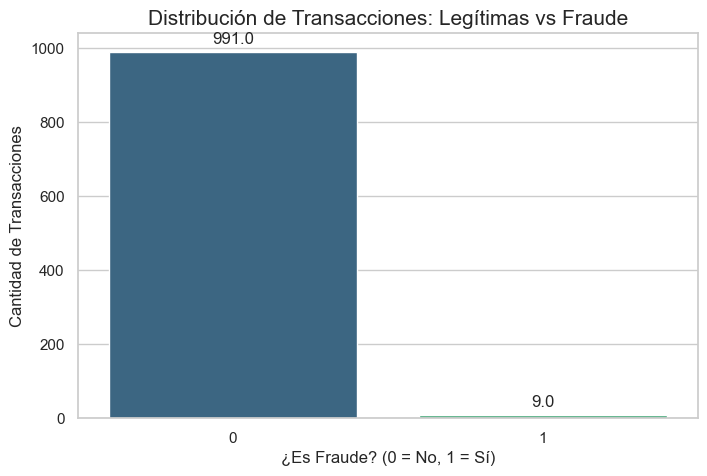

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el estilo
sns.set_theme(style="whitegrid")

# Creamos la gráfica
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='isFraud', data=df, hue='isFraud', palette='viridis', legend=False)

# Añadimos títulos y etiquetas
plt.title('Distribución de Transacciones: Legítimas vs Fraude', fontsize=15)
plt.xlabel('¿Es Fraude? (0 = No, 1 = Sí)', fontsize=12)
plt.ylabel('Cantidad de Transacciones', fontsize=12)

# Añadimos las etiquetas de cantidad sobre las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), 
                textcoords = 'offset points')

plt.show()

### 2. Análisis por Tipo de Transacción
Identificaremos en qué canales (`type`) se concentran los movimientos fraudulentos para enfocar nuestros esfuerzos de monitoreo.

In [12]:
# Cruzamos el tipo de transacción con los casos de fraude
fraud_by_type = pd.crosstab(df['type'], df['isFraud'])

# Calculamos el porcentaje de fraude por cada tipo para mayor claridad
fraud_by_type['% de Fraude'] = (fraud_by_type[1] / (fraud_by_type[0] + fraud_by_type[1])) * 100

print("Resumen de Fraude por Canal:")
fraud_by_type.sort_values(by='% de Fraude', ascending=False)

Resumen de Fraude por Canal:


isFraud,0,1,% de Fraude
type,,,
TRANSFER,95,4,4.040404
CASH_OUT,225,5,2.173913
CASH_IN,183,0,0.000000
DEBIT,51,0,0.000000
PAYMENT,437,0,0.000000


### 3. Análisis de Montos (Amount)
Compararemos los montos de las transacciones legítimas vs. las fraudulentas para identificar si existe un "monto típico" de fraude.

In [13]:
# Estadísticas descriptivas de los montos según si es fraude o no
resumen_montos = df.groupby('isFraud')['amount'].describe()

print("Comparativa de Montos:")
resumen_montos

Comparativa de Montos:


,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,991.0,116228.928809,243765.971191,8.73,4504.045,14420.66,142430.035,2545478.01
1,9.0,335184.096667,550601.115135,181.00,2806.000,20128.00,416001.330,1277212.77


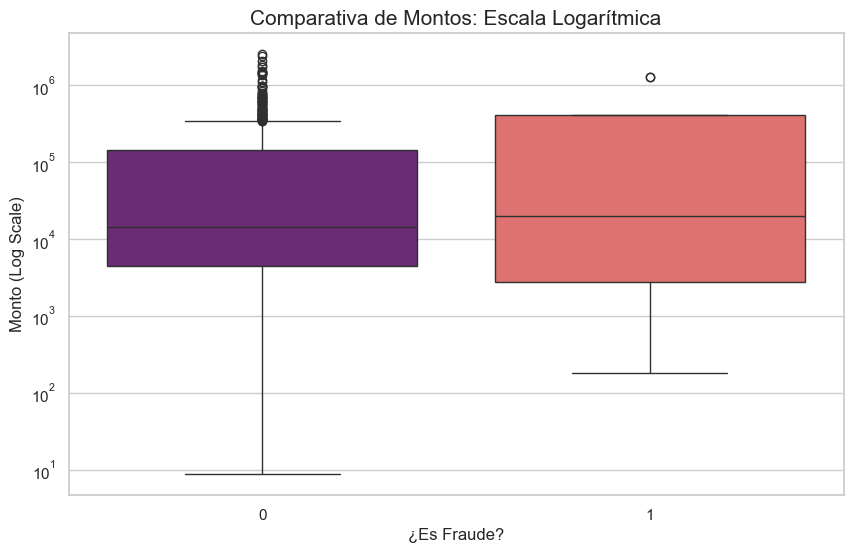

In [14]:
plt.figure(figsize=(10, 6))
# Usamos escala logarítmica porque los montos varían demasiado
sns.boxplot(x='isFraud', y='amount', data=df, palette='magma')
plt.yscale('log') # Fundamental para poder ver las cajas con montos tan diferentes

plt.title('Comparativa de Montos: Escala Logarítmica', fontsize=15)
plt.xlabel('¿Es Fraude?', fontsize=12)
plt.ylabel('Monto (Log Scale)', fontsize=12)
plt.show()